<a href="https://colab.research.google.com/github/jbkim900/Big-data-Analysis-Class_2026.03.12/blob/main/Chapter10_02_%EB%AF%B8%EC%84%B8%EB%B6%84%EC%84%9D_2026_03_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10장. 회귀분석 (2) 대기 오염 데이터 분석
# 4. 데이터 준비 및 탐색

In [3]:
import numpy as np
import pandas as pd

In [6]:
print(data_df.shape)

NameError: name 'data_df' is not defined

In [9]:
data_df = pd.read_csv('/content/대기오염데이터_종로구_20220401_20240215.csv', encoding='euc-kr')
data_df.isna().sum()

,0
location,0
day,0
so2,7
co,0
o3,0
no2,0
pm10,0
pm25,0


In [10]:
data_df = data_df.fillna(data_df['so2'].median())
data_df.isna().sum()  #작업 결과 확인

,0
location,0
day,0
so2,0
co,0
o3,0
no2,0
pm10,0
pm25,0


### 데이터 탐색을 위한 그래프 시각화

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50684 (\N{HANGUL SYLLABLE YEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54637 (\N{HANGUL SYLLABLE HANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

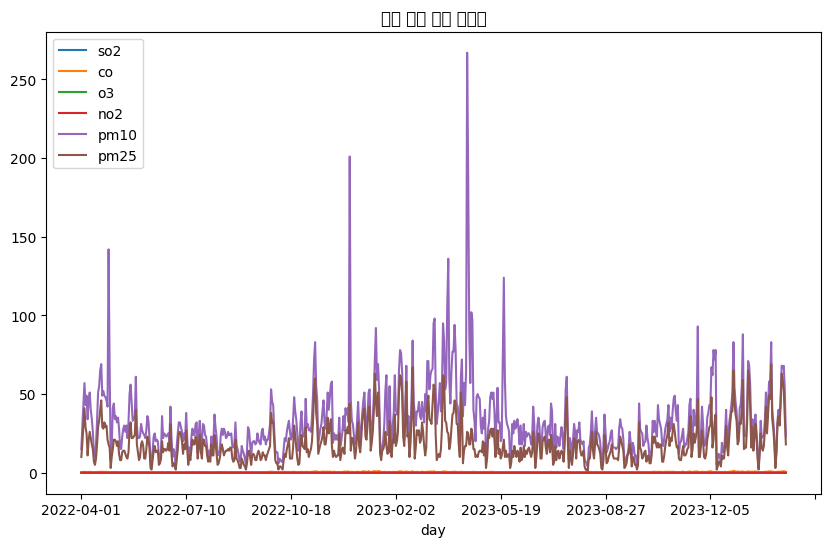

In [11]:
import matplotlib
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

graph_df = data_df.drop(['location'], axis = 1, inplace = False)
graph_df.set_index('day',inplace=True)
graph_df.plot(kind='line', figsize=(10, 6))  # kind='line'으로 선형 그래프 지정

plt.title('대기 오염 항목 그래프')
plt.xlabel('day')  # x 축 레이블 설정
plt.legend(loc='upper left')  # 범례 위치 설정
plt.show()

#### - 정규화하여 그래프 그리기

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
data_df2 = data_df.drop(['location', 'day'], axis = 1, inplace = False)
data_df2_scaled = StandardScaler().fit_transform(data_df2.values)
data_df2 = pd.DataFrame(data_df2_scaled)
data_df2.columns = ['so2','co','o3','no2','pm10','pm25']

In [14]:
day_df = data_df[['day']].copy()
graph_df2 = pd.concat([day_df, data_df2], axis=1)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50684 (\N{HANGUL SYLLABLE YEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54637 (\N{HANGUL SYLLABLE HANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

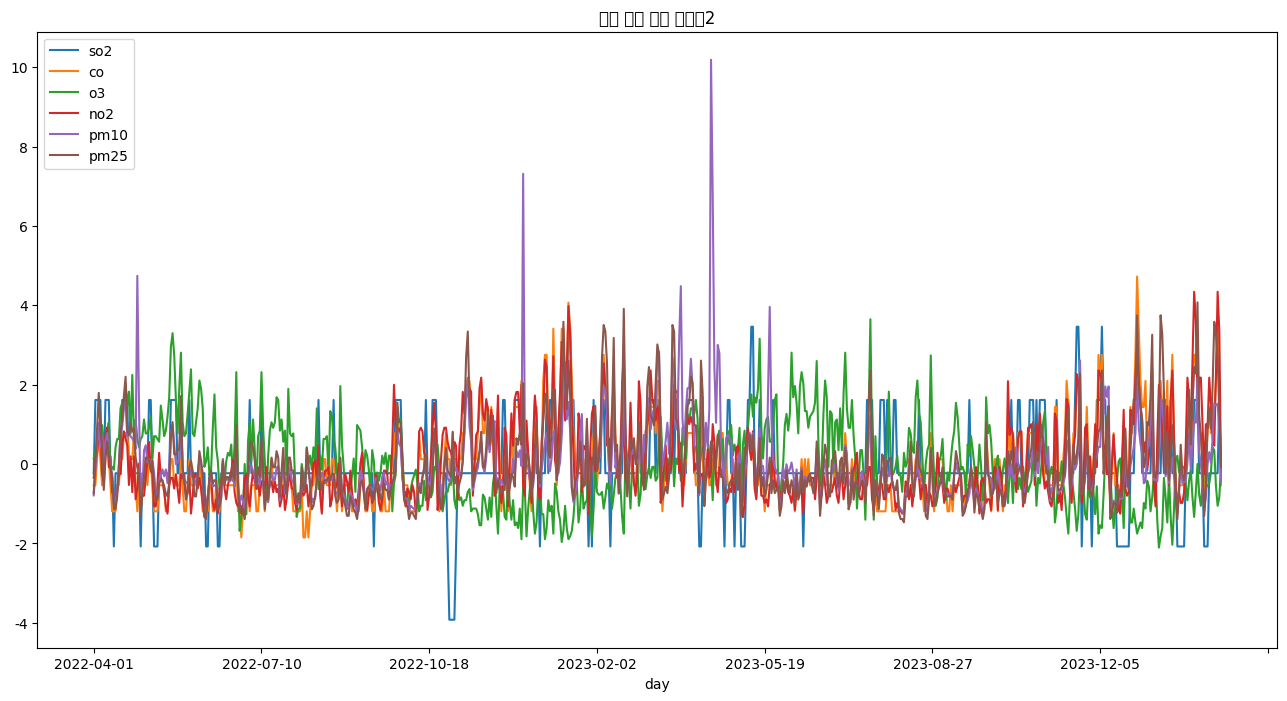

In [15]:
graph_df2.set_index('day',inplace=True)
graph_df2.plot(kind='line', figsize=(16, 8))
plt.title('대기 오염 항목 그래프2')
plt.xlabel('day')
plt.legend(loc='upper left')
plt.rcParams['axes.unicode_minus'] = False   #음수 부호 깨지지 않게 설정
plt.show()

# 5. 분석 모델 구축, 결과 분석 및 시각화

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# X, Y 분할하기
Y_pm10 = data_df['pm10']
Y_pm25 = data_df['pm25']
X = data_df.drop(['location', 'day','pm10', 'pm25'], axis=1, inplace=False)

## (1) 미세먼지 pm10 회귀 분석

### 회귀 분석 모델 구축

In [18]:
# 훈련용 데이터와 평가용 데이터 분할하기
X_train, X_test, Y_pm10_train, Y_pm10_test = train_test_split(X, Y_pm10, test_size=0.3, random_state=156)

In [19]:
# 선형회귀분석 : 모델 생성
lr_pm10 = LinearRegression()

In [20]:
# 선형회귀분석 : 모델 훈련
lr_pm10.fit(X_train, Y_pm10_train)

LinearRegression()

In [21]:
# 선형회귀분석 : 평가 데이터에 대한 예측 수행 -> 예측 결과 Y_predict 구하기
Y_pm10_predict = lr_pm10.predict(X_test)

In [22]:
# 선형회귀분석 : 평가 데이터에 대한 예측 수행 -> 예측 결과 Y_predict 구하기
Y_pm10_predict = lr_pm10.predict(X_test)

###  결과 분석 - 모델 평가

In [23]:
mse = mean_squared_error(Y_pm10_test, Y_pm10_predict)
rmse = np.sqrt(mse)

print('MSE : {0:.3f}, RMSE : {1:.3f}'.format(mse, rmse))
print('R^2(Variance score) : {0:.3f}'.format(r2_score(Y_pm10_test, Y_pm10_predict)))

MSE : 293.367, RMSE : 17.128
R^2(Variance score) : 0.344


In [24]:
print('Y_pm10 절편 값: ', lr_pm10.intercept_)
print('회귀 계수 값: ', np.round(lr_pm10.coef_, 1))

Y_pm10 절편 값:  -24.637204220135352
회귀 계수 값:  [2512.8   55.2  444.8  447.3]


In [25]:
coef = pd.Series(data = np.round(lr_pm10.coef_, 2), index=X.columns)
coef.sort_values(ascending = False)

,0
so2,2512.75
no2,447.27
o3,444.80
co,55.18


###  회귀 분석 결과를 산점도 + 선형 회귀 그래프로 시각화

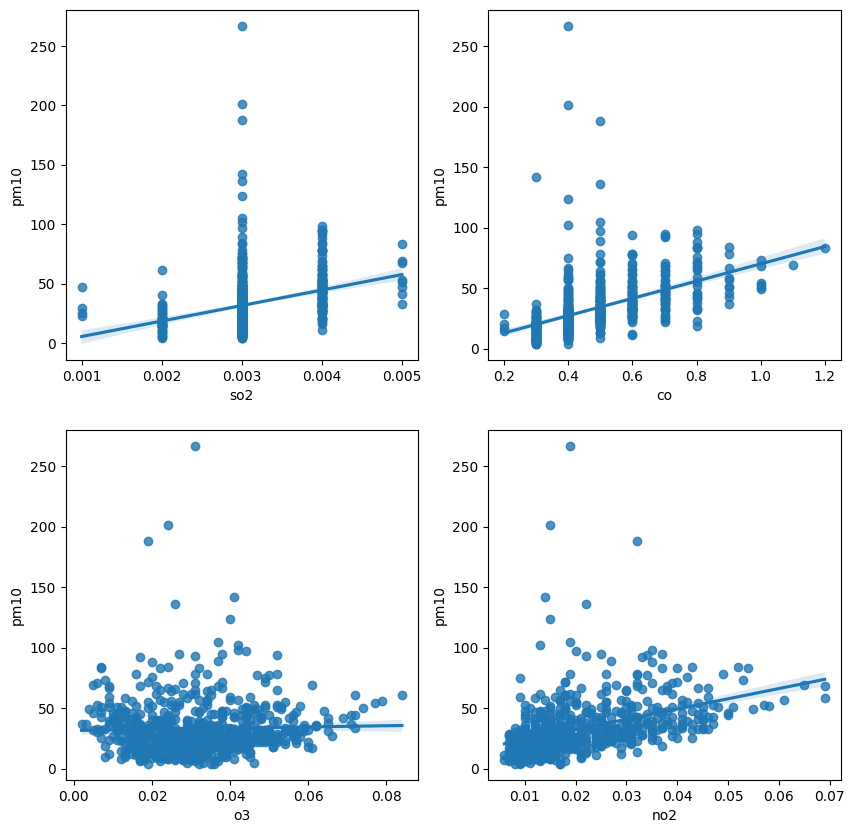

In [26]:
fig, axs = plt.subplots(figsize=(10, 10), ncols=2, nrows=2)
x_features = ['so2', 'co', 'o3', 'no2']

for i, feature in enumerate(x_features):
      row = int(i/2)
      col = i%2
      sns.regplot(x=feature, y='pm10', data=data_df, ax=axs[row][col])

## (2) 초세먼지 pm25 회귀 분석
### 회귀 분석 모델 구축

In [27]:
# 훈련용 데이터와 평가용 데이터 분할하기
X_train, X_test, Y_pm25_train, Y_pm25_test = train_test_split(X, Y_pm25, test_size=0.3, random_state=156)

In [28]:
# 선형회귀분석 : 모델 생성
lr_pm25 = LinearRegression()

In [29]:
# 선형회귀분석 : 모델 훈련
lr_pm25.fit(X_train, Y_pm25_train)

LinearRegression()

In [30]:
# 선형회귀분석 : 평가 데이터에 대한 예측 수행 -> 예측 결과 Y_predict 구하기
Y_pm25_predict = lr_pm25.predict(X_test)

In [31]:
# 선형회귀분석 : 평가 데이터에 대한 예측 수행 -> 예측 결과 Y_predict 구하기
Y_pm25_predict = lr_pm25.predict(X_test)

###  결과 분석 - 모델 평가

In [32]:
mse = mean_squared_error(Y_pm25_test, Y_pm25_predict)
rmse = np.sqrt(mse)

print('MSE : {0:.3f}, RMSE : {1:.3f}'.format(mse, rmse))
print('R^2(Variance score) : {0:.3f}'.format(r2_score(Y_pm25_test, Y_pm25_predict)))

MSE : 51.813, RMSE : 7.198
R^2(Variance score) : 0.661


In [33]:
print('Y_pm25 절편 값: ', lr_pm25.intercept_)
print('회귀 계수 값: ', np.round(lr_pm25.coef_, 1))

Y_pm25 절편 값:  -22.952459871175424
회귀 계수 값:  [776.   61.5 218.2 136.8]


In [34]:
coef = pd.Series(data = np.round(lr_pm25.coef_, 2), index=X.columns)
coef.sort_values(ascending = False)

,0
so2,776.01
o3,218.18
no2,136.83
co,61.50


### - 회귀 분석 결과를 산점도 + 선형 회귀 그래프로 시각화

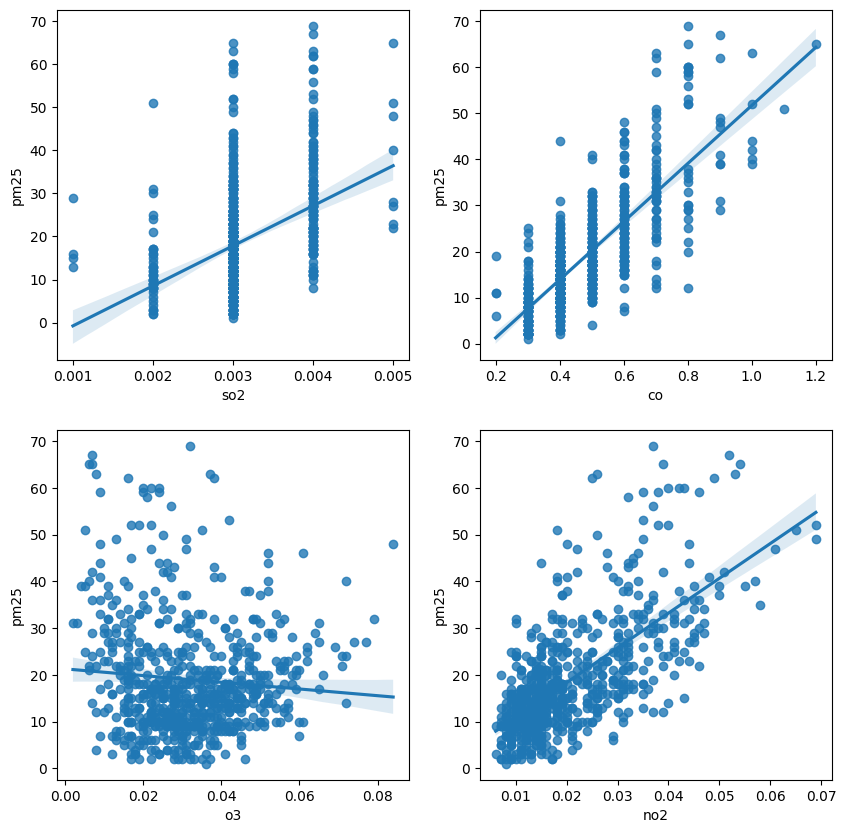

In [35]:
fig, axs = plt.subplots(figsize=(10, 10), ncols=2, nrows=2)
x_features = ['so2', 'co', 'o3', 'no2']

for i, feature in enumerate(x_features):
      row = int(i/2)
      col = i%2
      sns.regplot(x=feature, y='pm25', data=data_df, ax=axs[row][col])